# Figure S12. Lifestyle benchmarks

In [25]:
### load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
plt.rcParams.update({'font.size': 14})

In [26]:
### Download checkv provirus info
# !wget https://portal.nersc.gov/UHGV/mysql/tsv/checkv_contamination.tsv
# !wget https://portal.nersc.gov/UHGV/mysql/tsv/genomad_viral_stats.tsv

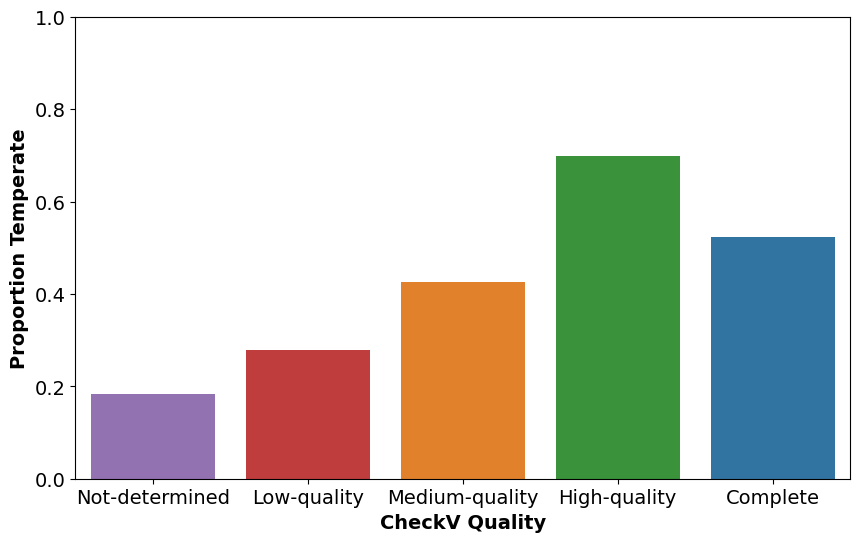

In [27]:
### UHGV prop temperate by completeness
conf_votus = (
    pl.read_csv('votus_metadata_extended.tsv', null_values='NULL', separator='\t', ignore_errors=True, columns=['uhgv_votu', 'bacphlip_temperate_score', 'uhgv_genome', 'checkv_quality', 'checkv_completeness', 'has_integrase', 'viral_confidence', 'lifestyle', 'lifestyle_evidence'])
)

checkv_provirus = (
    pl.read_csv('checkv_contamination.tsv', separator='\t', ignore_errors=True, null_values=['NULL'], columns=['contig_id', 'provirus', 'host_genes', 'host_length'])
        .rename({'contig_id':'uhgv_genome', 'provirus':'checkv_provirus'})
        .with_columns([
            pl.col('host_length').cast(pl.Float64)
        ])
)

genomad_provirus = (
    pl.read_csv('genomad_viral_stats.tsv', separator='\t', ignore_errors=True, columns=['contig_id', 'provirus'])
        .rename({'contig_id':'uhgv_genome', 'provirus':'genomad_provirus'})
)

contig2integrase = (
    pl.read_csv('../figure_s6/contig_to_integrase.tsv', separator='\t', ignore_errors=True)
)

combined = (
    conf_votus.join(checkv_provirus, on='uhgv_genome', how='left', coalesce=True).join(genomad_provirus, on='uhgv_genome', how='left', coalesce=True)
        .group_by(pl.col('checkv_quality'))
        .agg([
            (pl.col('lifestyle') != 'lytic').sum().alias('num_temperate'),
            pl.len().alias('total')
        ])
        .with_columns([
            (pl.col('num_temperate') / pl.col('total')).alias('prop_temperate')
        ])
)

# plot prop temperate by quality category
# make figure wider
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=combined,
    x='checkv_quality',
    y='prop_temperate',
    hue='checkv_quality',
    order=['Not-determined', 'Low-quality', 'Medium-quality', 'High-quality', 'Complete']
)

ax.set_xlabel('CheckV Quality', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Proportion Temperate', fontdict={'fontweight': 'bold'})
ax.set_ylim(0, 1)
plt.show()

In [28]:
# map from original id to species
seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping = pl.concat([
    pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t'),
    pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t')
])
seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
uhvdb_source_meta = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')
genomovar_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')

combined = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .join(genomovar_info[['uhvdb_id', 'votu_rep']], left_on='new_id', right_on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep']], left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .join(aaicluster, left_on='votu_rep', right_on='uhvdb_id', how='left')
        .filter((pl.col('new_id') == pl.col('genomovar_rep')))
        .unique('genomovar_rep')
)

In [41]:
uhgv_classification = (
    pl.read_csv('votus_metadata_extended.tsv', null_values='NULL', separator='\t', ignore_errors=True, columns=['uhgv_votu', 'bacphlip_temperate_score', 'uhgv_genome', 'checkv_quality', 'checkv_completeness', 'has_integrase', 'viral_confidence', 'lifestyle', 'lifestyle_evidence'])
)
uhvdb_classification = (
    pl.read_csv('../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/uhvdb_lifestyle.tsv.gz', separator='\t')
        .join(uhvdb_mapping[['original_id', 'new_id']], left_on='uhvdb_id', right_on='new_id', how='left').rename({'original_id':'uhgv_genome'})
)
uhgv_uhvdb_joined = (
    uhgv_classification.join(uhvdb_classification, on='uhgv_genome', how='inner')
)

In [43]:
uhgv_uhvdb_joined

uhgv_genome,uhgv_votu,checkv_quality,checkv_completeness,viral_confidence,bacphlip_temperate_score,has_integrase,lifestyle,lifestyle_evidence,uhvdb_id,topology,provirus,virulent,temperate,phrog_integrases,phrog_integration_excision,empathi_integration
str,str,str,f64,str,f64,str,str,str,str,str,str,f64,f64,i64,i64,i64
"""UHGV-0121692""","""vOTU-000001""","""Complete""",100.0,"""Confident""",0.1625,"""No""","""lytic""","""BACPHLIP""","""UHVDB-39904""","""No terminal repeats""","""No""",0.8375,0.1625,null,null,1
"""UHGV-0169522""","""vOTU-000002""","""Complete""",100.0,"""Confident""",0.2125,"""No""","""lytic""","""BACPHLIP""","""UHVDB-53875""","""No terminal repeats""","""No""",0.7875,0.2125,1,null,4
"""UHGV-1368950""","""vOTU-000004""","""Complete""",100.0,"""Confident""",0.125,"""No""","""lytic""","""BACPHLIP""","""UHVDB-106264""","""No terminal repeats""","""No""",0.875,0.125,1,null,3
"""UHGV-0062920""","""vOTU-000005""","""Complete""",100.0,"""Confident""",0.244934,"""No""","""lytic""","""BACPHLIP""","""UHVDB-24264""","""No terminal repeats""","""No""",0.755066,0.244934,null,null,1
"""UHGV-1512861""","""vOTU-000007""","""Complete""",100.0,"""Confident""",0.0386977,"""No""","""lytic""","""BACPHLIP""","""UHVDB-146261""","""No terminal repeats""","""No""",0.961302,0.038698,null,1,3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""UHGV-0034819""","""vOTU-163662""","""Complete""",100.0,"""Confident""",0.9875,"""No""","""temperate""","""BACPHLIP""","""UHVDB-16269""","""No terminal repeats""","""No""",0.0125,0.9875,4,6,11
"""UHGV-0081657""","""vOTU-164229""","""High-quality""",91.82,"""Confident""",0.95,"""Yes""","""temperate""","""integrase""","""UHVDB-29422""","""No terminal repeats""","""No""",0.05,0.95,1,1,1
"""UHGV-1363755""","""vOTU-164506""","""Complete""",100.0,"""Confident""",0.05,"""No""","""lytic""","""BACPHLIP""","""UHVDB-102880""","""No terminal repeats""","""No""",0.95,0.05,null,null,1


In [44]:
### Count number of UHGV viruses classified as temperate by each method
# load uhvdb classifications
uhvdb_lifestyles = (
    pl.read_csv('../figure_3/uhvdb_v4_lifestyle.tsv', separator='\t')
)

uhvdb_lifestyles.height

508382

In [45]:
### Identify viruses that were integrated in first run
original_classify_proviruses = set(
    pl.read_csv('../figure_1/viruses.csvtk_concat.tsv', separator='\t', columns=['topology', 'provirus', 'seq_name'])
        .filter((pl.col('topology') == 'Provirus') | (pl.col('provirus') == 'Yes'))
        ['seq_name']
)

In [46]:
### load UHGV integration data

# # Download genomad stats file
# !wget https://portal.nersc.gov/cfs/m342/UHGV/mysql/tsv/genomad_viral_stats.tsv

uhgv_proviruses = set(
    pl.read_csv('genomad_viral_stats.tsv', separator='\t', columns=['contig_id', 'provirus'])
    .filter(pl.col('provirus') == "Yes")
    ['contig_id']
)

### get OPD provirus info
# 1. download Excel sheet with metadata: https://static-content.springer.com/esm/art%3A10.1038%2Fs41522-025-00773-z/MediaObjects/41522_2025_773_MOESM2_ESM.xlsx
# 2. Filter Table3-OPD quality to identify 'replace_id' with 'checkv_provirus' == "Yes"
# 3. Save as TSV: opd_checkv_proviruses.tsv
opd_proviruses = set(
    pl.read_csv('../figure_3/opd_checkv_provirus.tsv', separator='\t', columns=['replace_id'])
    ['replace_id']
)

### Get CNGVC integration information
# CNGVC did not perform host trimming, so just used UHVDB provirus info

#### get CGVR provirus info
# 1. CGVR metadata downloaded from: https://static-content.springer.com/esm/art%3A10.1186%2Fs40168-025-02185-9/MediaObjects/40168_2025_2185_MOESM1_ESM.xlsx
# 2. Filter Table S1 to identify 'Viral_bin_id' with 'provirus' == "Yes"
# 3. Save as TSV: cgvr_checkv_proviruses.tsv
cgvr_proviruses = set(
    pl.read_csv('../figure_3/cgvr_checkv_proviruses.tsv', separator='\t', columns=['Viral_bin_id'])
    ['Viral_bin_id']
)

### get IMGVR integration info
# 1. Download IMGVR metadata from: https://genome.jgi.doe.gov/portal/pages/dynamicOrganismDownload.jsf?organism=IMG_VR
imgvr_proviruses = set(
    pl.read_csv('../figure_1/IMGVR_all_Sequence_information.tsv', separator='\t', columns=['UVIG', 'Topology'])
        .filter(pl.col('Topology') == 'Provirus')
        ['UVIG']
)

### get mMGE provirus info
# 1. Download mMGE metadata from: https://mai.fudan.edu.cn/mgedb/client/file/all_mge_inf.zip
mmge_proviruses = set(
    pl.read_csv('../figure_1/all_mge_inf.csv')
        .filter(pl.col('prophage') == True)
        ['MGEs_id']
)

integrated_seqs = (
    uhgv_proviruses
    .union(opd_proviruses)
    .union(cgvr_proviruses)
    .union(imgvr_proviruses)
    .union(mmge_proviruses)
    .union(original_classify_proviruses)
)
len(integrated_seqs)

1385581

In [47]:
uhvdb_integrated_inputs = set(combined.filter(pl.col('seq_name').is_in(integrated_seqs))['new_id'])

In [48]:
uhvdb_lifestyles

uhvdb_id,topology,provirus,virulent,temperate,phrog_integrases,phrog_integration_excision,empathi_integration
str,str,str,f64,f64,str,i64,i64
"""UHVDB-406973""","""No terminal repeats""","""No""",0.5375,0.4625,null,1,1
"""UHVDB-406306""","""No terminal repeats""","""No""",0.924871,0.075129,null,null,1
"""UHVDB-406625""","""No terminal repeats""","""No""",0.4875,0.5125,null,null,null
"""UHVDB-406281""","""No terminal repeats""","""No""",0.0,1.0,null,null,1
"""UHVDB-407129""","""No terminal repeats""","""No""",0.0,1.0,null,null,1
…,…,…,…,…,…,…,…
"""UHVDB-181287""","""No terminal repeats""","""No""",0.0,1.0,null,null,null
"""UHVDB-181923""","""No terminal repeats""","""No""",0.147522,0.852478,null,null,1
"""UHVDB-181159""","""No terminal repeats""","""No""",0.0125,0.9875,null,null,1


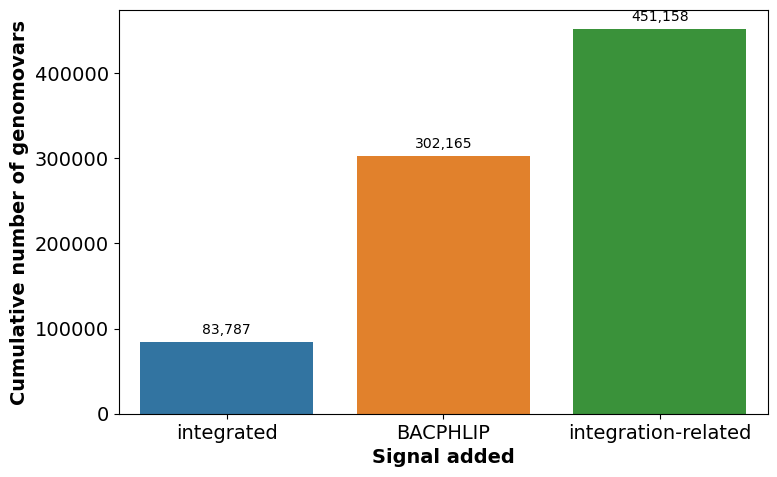

signal,cumulative_count
str,i64
"""integrated""",83787
"""BACPHLIP""",302165
"""integration-related""",451158


In [49]:
### Barplot: cumulative count as each temperate signal is added
signal_order = [
    'integrated',
    'BACPHLIP',
    'integration-related'
]

signal_exprs = {
    'integrated': (pl.col('uhvdb_id').is_in(uhvdb_integrated_inputs)).fill_null(False),
    'BACPHLIP': (pl.col('temperate').cast(pl.Float64, strict=False) > 0.5).fill_null(False),
    'integration-related': (
        (pl.col('phrog_integrases').cast(pl.Float64, strict=False) >= 1)
        | (pl.col('phrog_integration_excision').cast(pl.Float64, strict=False) >= 1)
        | (pl.col('empathi_integration').cast(pl.Float64, strict=False) >= 1)
    ).fill_null(False),
}

cumulative_records = []
cumulative_expr = pl.lit(False)

for signal in signal_order:
    cumulative_expr = cumulative_expr | signal_exprs[signal]
    n_cumulative = uhvdb_lifestyles.filter(cumulative_expr).height
    cumulative_records.append({
        'signal': signal,
        'cumulative_count': n_cumulative,
    })

cumulative_signal_counts = pl.DataFrame(cumulative_records)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=cumulative_signal_counts.to_pandas(),
    x='signal',
    y='cumulative_count',
    hue='signal',
    dodge=False,
    ax=ax
)

# Add counts above each bar
for patch, count in zip(ax.patches, cumulative_signal_counts['cumulative_count'].to_list()):
    ax.annotate(
        f"{count:,}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 4),
        textcoords='offset points',
        fontsize=10
    )

ax.set_xlabel('Signal added', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Cumulative number of genomovars', fontdict={'fontweight': 'bold'})
plt.tight_layout()
plt.show()

cumulative_signal_counts

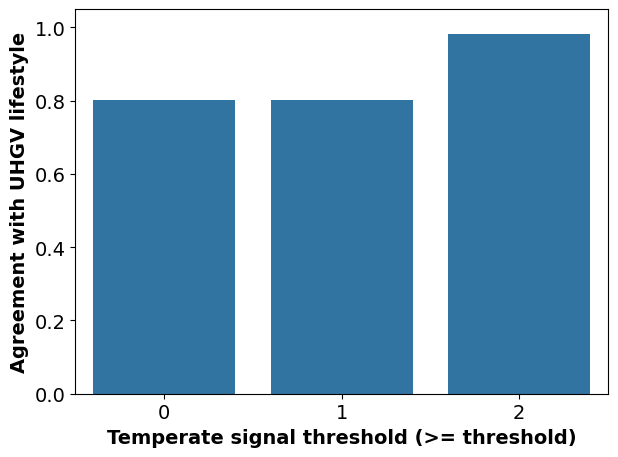

threshold,n_genomes,n_agree,agreement_prop
i64,i64,i64,f64
0,39972,32071,0.802337
1,39972,32037,0.801486
2,39972,39199,0.980661


In [54]:
### Compare agreement between UHGV and UHVDB using thresholded temperate signal count
temperate_classifications = (
    uhgv_uhvdb_joined
        .with_columns([
            (
                (pl.col('uhvdb_id').is_in(uhvdb_integrated_inputs)).fill_null(False).cast(pl.Int32) +
                ((pl.col('temperate') > 0.5)).fill_null(False).cast(pl.Int32) +
                ((pl.col('phrog_integration_excision') >= 1) | (pl.col('empathi_integration') >= 1)).fill_null(False).cast(pl.Int32)
            ).alias('temperate_signal_count'),
            (pl.col('lifestyle') != 'lytic').fill_null(False).alias('uhgv_temperate'),
        ])
        .filter((pl.col('lifestyle') == 'temperate') | (pl.col('temperate_signal_count') > 0))
)

max_signal_count = int(temperate_classifications['temperate_signal_count'].max())

agreement_by_threshold = pl.DataFrame([
    {
        'threshold': threshold,
        'n_genomes': temperate_classifications.height,
        'n_agree': (
            temperate_classifications
                .with_columns((pl.col('temperate_signal_count') >= threshold).alias('uhvdb_temperate_from_signals'))
                .with_columns((pl.col('uhgv_temperate') == pl.col('uhvdb_temperate_from_signals')).alias('agreement'))
                .filter(pl.col('agreement'))
                .height
        ),
        'agreement_prop': (
            temperate_classifications
                .with_columns((pl.col('temperate_signal_count') >= threshold).alias('uhvdb_temperate_from_signals'))
                .with_columns((pl.col('uhgv_temperate') == pl.col('uhvdb_temperate_from_signals')).alias('agreement'))
                .select(pl.col('agreement').mean())
                .item()
        )
    }
    for threshold in range(0, max_signal_count )
])

fig, ax = plt.subplots()
sns.barplot(
    data=agreement_by_threshold.to_pandas(),
    x='threshold',
    y='agreement_prop',
    ax=ax
)

ax.set_xlabel('Temperate signal threshold (>= threshold)', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Agreement with UHGV lifestyle', fontdict={'fontweight': 'bold'})
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

agreement_by_threshold